In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

np.random.seed(24)

Import tables for viz

In [2]:
#CIN and community cohesion tables
ccc_df = pd.read_pickle('cin_cc_df')
cc_gb = pd.read_pickle("cc_gb.pkl")
cc_lna = pd.read_pickle("cc_gb_lna.pkl")
cc_np = pd.read_pickle("cc_gb_np.pkl")

#Metatopic tables
meta_df = pd.read_pickle("meta_df.pkl")
meta_gb = pd.read_pickle("meta_gb.pkl")
meta_lna = pd.read_pickle("meta_gb_lna.pkl")
meta_np = pd.read_pickle("meta_gb_np.pkl")

#IPTC tables
iptc_df = pd.read_pickle("iptc_df.pkl")
iptc_gb = pd.read_pickle("iptc_gb.pkl")
iptc_lna = pd.read_pickle("iptc_gb_lna.pkl")
iptc_np = pd.read_pickle("iptc_gb_np.pkl")

### Viz for CIN and CC

In [3]:
ccc_df[['CIN','Community','Mixed']].mean()

CIN          0.257079
Community    0.719788
Mixed        0.018373
dtype: float64

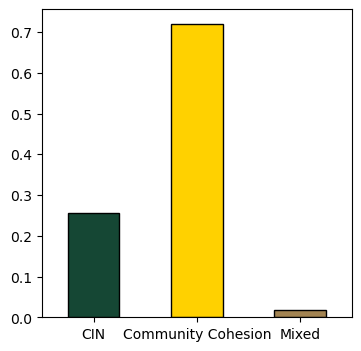

In [4]:
plt.subplots(figsize=(4, 4))
ax = ccc_df[['CIN','Community','Mixed']].mean().plot.bar(color=['#154734','#FFD100','#A38452'], edgecolor='black')
#ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
ax.set_xticks([0,1,2], rotation=0, labels=["CIN", "Community Cohesion","Mixed"])
plt.show()

In [5]:
cc_gb

CIN  Community     Mixed
news_partnership LNA                               
0.0              0    0.212520   0.749313  0.033600
                 1    0.204513   0.777356  0.013276
1.0              0    0.562768   0.417731  0.014892
                 1    0.455701   0.523249  0.016330

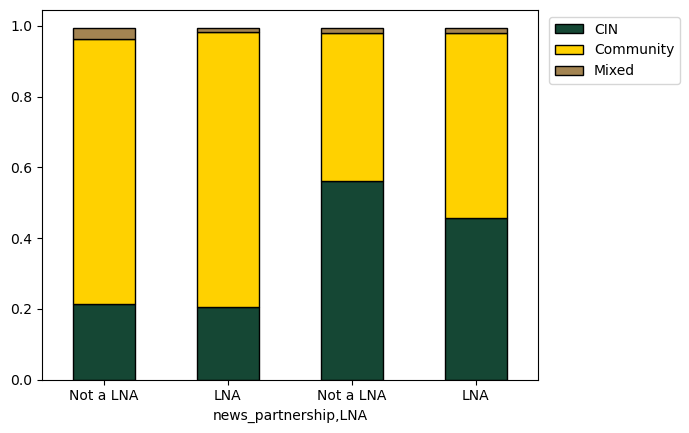

In [6]:
ax = cc_gb.plot.bar(stacked=True, color=['#154734','#FFD100','#A38452'], edgecolor='black')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
ax.set_xticks([0,1,2,3], rotation=0, labels=["Not a LNA", "LNA","Not a LNA","LNA"])

In [7]:
#create the LNA into a column w/ words
cc_lna.reset_index(inplace=True)
for i, row in cc_lna.iterrows():
    if row["LNA"] == 1:
        cc_lna.loc[i,"LNA"] = "LNA"
    else:
        cc_lna.loc[i,"LNA"] = "Not a LNA"

C:\Users\Intern\AppData\Local\Temp\ipykernel_46228\2158940654.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Not a LNA' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cc_lna.loc[i,"LNA"] = "Not a LNA"


In [8]:
cc_lna

,LNA,CIN,Community,Mixed
0,Not a LNA,0.275688,0.689711,0.030027
1,LNA,0.249747,0.731638,0.013781


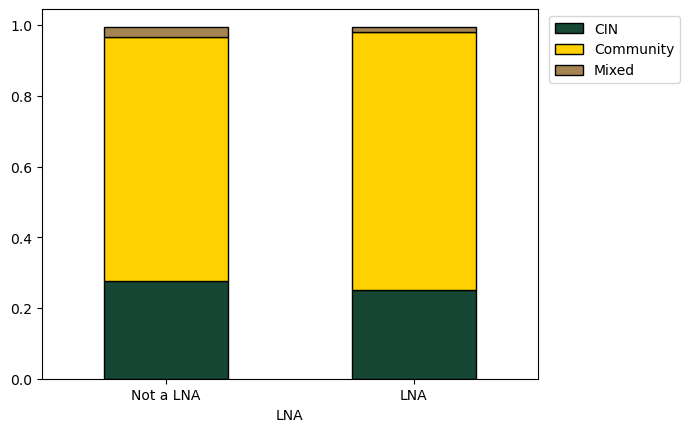

In [9]:
ax = cc_lna.plot.bar(x='LNA',stacked=True, color=['#154734','#FFD100','#A38452'], edgecolor='black')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
ax.set_xticks([0,1], rotation=0, labels=["Not a LNA", "LNA"])
plt.show()

In [10]:
#create the LNA into a column w/ words
cc_np.reset_index(inplace=True)
for i, row in cc_np.iterrows():
    if row["news_partnership"] == 1:
        cc_np.loc[i,"news_partnership"] = "News Partnership"
    else:
        cc_np.loc[i,"news_partnership"] = "Not a News Partnership"

C:\Users\Intern\AppData\Local\Temp\ipykernel_46228\2911383214.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Not a News Partnership' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  cc_np.loc[i,"news_partnership"] = "Not a News Partnership"


In [11]:
cc_np

,news_partnership,CIN,Community,Mixed
0,Not a News Partnership,0.206771,0.769448,0.019008
1,News Partnership,0.486030,0.493359,0.015923


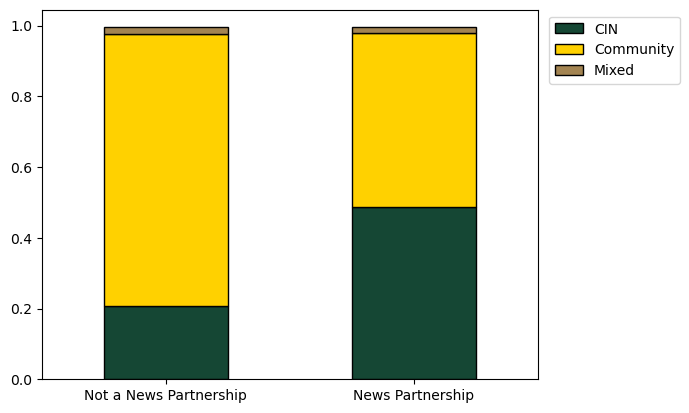

In [12]:
ax = cc_np.plot.bar(stacked=True, color=['#154734','#FFD100','#A38452'], edgecolor='black')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1))
ax.set_xticks([0,1], rotation=0, labels=["Not a News Partnership","News Partnership"])

### Viz for Metatopics

In [13]:
meta_gb.rename(columns={'None':'Mixed'}, inplace=True)

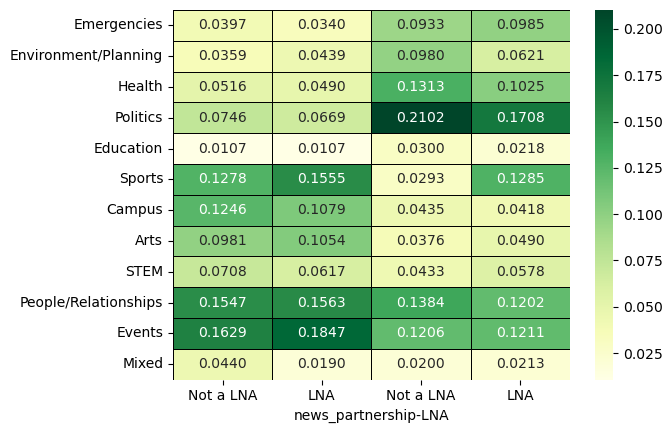

In [14]:
ax = sns.heatmap(meta_gb.transpose(), annot=True,fmt=".4f",cmap="YlGn",linewidth=.5, linecolor="black")
ax.set_xticks([0.5,1.5,2.5,3.5], rotation=0, labels=["Not a LNA", "LNA","Not a LNA","LNA"])

### Viz for IPTC

In [27]:
glue = sns.load_dataset("glue").pivot(index="Model", columns="Task", values="Score")
glue

Task,CoLA,MNLI,MRPC,QNLI,QQP,RTE,SST-2,STS-B
Model,,,,,,,,
BERT,60.5,86.7,89.3,92.7,72.1,70.1,94.9,87.6
BiLSTM,11.6,65.6,81.8,74.6,62.5,57.4,82.8,70.3
BiLSTM+Attn,18.6,67.6,83.9,74.3,60.1,58.4,83.0,72.8
BiLSTM+CoVe,18.5,65.4,78.7,70.8,60.6,52.7,81.9,64.4
BiLSTM+ELMo,32.1,67.2,84.7,75.5,61.1,57.4,89.3,70.3
ERNIE,75.5,92.3,93.9,97.3,75.2,92.6,97.8,93.0
RoBERTa,67.8,90.8,92.3,95.4,74.3,88.2,96.7,92.2
T5,71.6,92.2,92.8,96.9,75.1,92.8,97.5,93.1


In [18]:
iptc_gb = iptc_gb[['politics','crime','economy','environment','society','education','arts/media','sports','lifestyle','none']]

In [19]:
iptc_gb.transpose()

news_partnership       0.0                 1.0          
LNA                      0         1         0         1
politics          0.074598  0.066902  0.210240  0.170842
crime             0.039660  0.034020  0.093279  0.098465
economy           0.024498  0.024864  0.079183  0.049068
environment       0.034084  0.038693  0.055223  0.044965
society           0.154720  0.156331  0.138391  0.120226
education         0.135296  0.118692  0.073440  0.063563
arts/media        0.240909  0.257643  0.124911  0.144734
sports            0.170019  0.194553  0.128689  0.211647
lifestyle         0.054260  0.049349  0.058280  0.046370
none              0.043959  0.018980  0.019966  0.021252

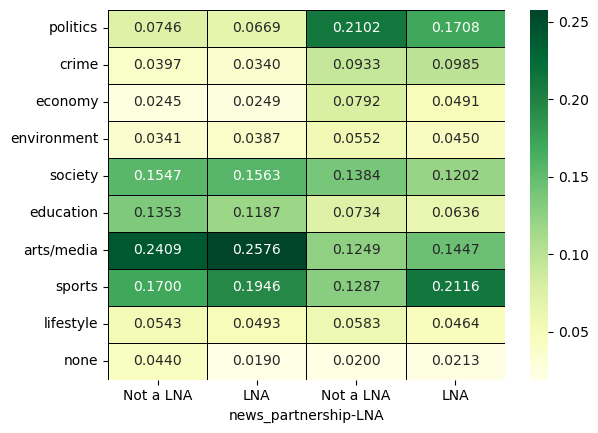

In [20]:
ax = sns.heatmap(iptc_gb.transpose(), annot=True,fmt=".4f",cmap="YlGn",linewidth=.5, linecolor="black")
ax.set_xticks([0.5,1.5,2.5,3.5], rotation=0, labels=["Not a LNA", "LNA","Not a LNA","LNA"])

## Stats

#### All data comparison

I will be using a one sample t-test to determine if communtiy cohesion is discussed more that CIN. If community cohesion and CIN are discussed in the same proportion, than the difference will be 0. However, we expect that community cohesion will have a higher proportion because it includes the two campus topics, which college papers are most likely to discuss.

In [22]:
dif_ccc = ccc_df['Community']-ccc_df['CIN']

##### Independence

This assumption is mostly met. The majority of the observations are independent of each other, but some of the publications do come from the same institution making them not independent. We will continue with our analysis even if this assumption is not perfectly met.

##### Normality

As seen in the histogram below the difference between the proprtion community cohesion and CIN are discussed is extreamly left skewed. We tried transforming it, but squaring it, cubing it, and taking the exponent were all still left skewed due to the frequency of 1s. Because of this we decided to perform a non-parametric test.

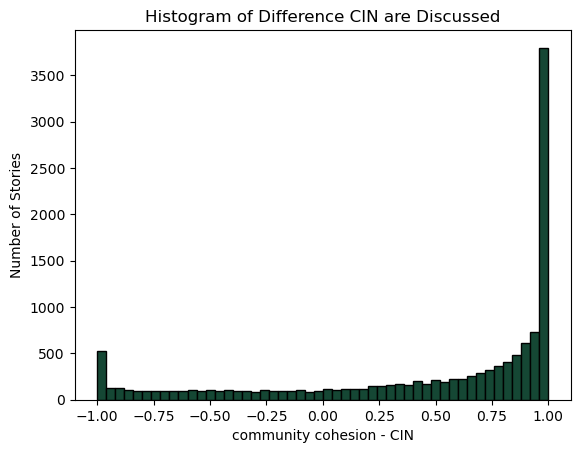

In [23]:
#histogram of the CIN percent
plt.hist(x=dif_ccc, bins=50, edgecolor='black',color='#154734')
plt.title("Histogram of Difference CIN are Discussed")
plt.xlabel("community cohesion - CIN")
plt.ylabel("Number of Stories")
plt.show()

##### Outliers

As seen in the boxplot below there no outliers.

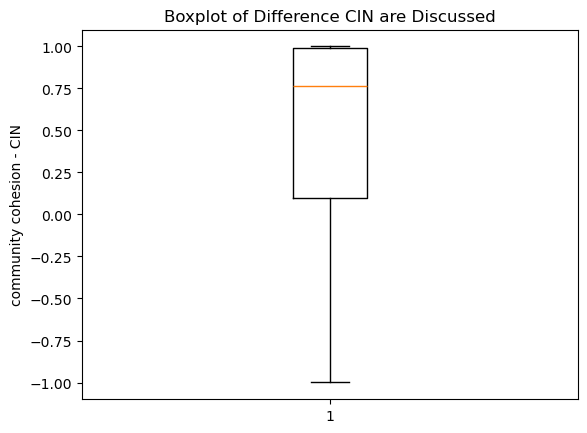

In [24]:
plt.boxplot(x=dif_ccc)
plt.title("Boxplot of Difference CIN are Discussed")
plt.ylabel("community cohesion - CIN")
plt.show()

Because Normality and Outliers were not met, we will be usin the non-parametric Wilcoxon signed-rank test that is sutable for a one-sample hypothesis tets (https://pmc.ncbi.nlm.nih.gov/articles/PMC4754273/#sec12).

$\hat{\delta}$ = the median of the proportion community cohesion is discussed minus the proportion CIN are discussed

$H_0: \hat{\delta}$ = 0 -- The median diffence between community cohesion and CIN is zero

$H_a: \hat{\delta}$ > 0 -- The median diffence between community cohesion and CIN is greater than zero. This is a one sided test because we expect that college papers discuss their campus quite frequently, and we categoriez our campus related topics as community.

In [27]:
#this is for skewed data - https://pmc.ncbi.nlm.nih.gov/articles/PMC4754273/#sec5
ccc_wiltest = stats.wilcoxon(dif_ccc - 0, alternative='greater')
ccc_wiltest

WilcoxonResult(statistic=np.float64(67085852.5), pvalue=np.float64(0.0))

Because our p-value of 0.0 is less than our chosen significance level of 0.01, we have extreamly strong evidence to reject the null hypothesis. This means we have evidence in favor of the alternative hypothesis that the median diffence between community cohesion and CIN is greater than zero. In the context of our study, this means we have evidence that college papers discuss community cohesion more than CIN.

#### News Partnership comparison

We will be using a 2-sample t-test to determine if NP discuss CIN more than non NP. The assumptions are independence between and within samples, normality for both samples, and equal variance.

##### Independence

Independence is not fully met. Most of the observations within samples are independent, but some may come from the same institution. The main reason independence is not met is because multiple institutions have a news partnership publication and a regular studen run publication. This means the are not truely independent, but we will continue with our analysis regardless.

#### Normality

As seen in the density plot below normality is not met. news partnerships are slightly right skewed. Non news partnerships are extreamly right skewed. These values (espeshally the non news partnerships) cannot be transformed because the most common forms of transformations for right skewed data do not affect 0 values. This means we will be doing a non-parametric t-test on them.

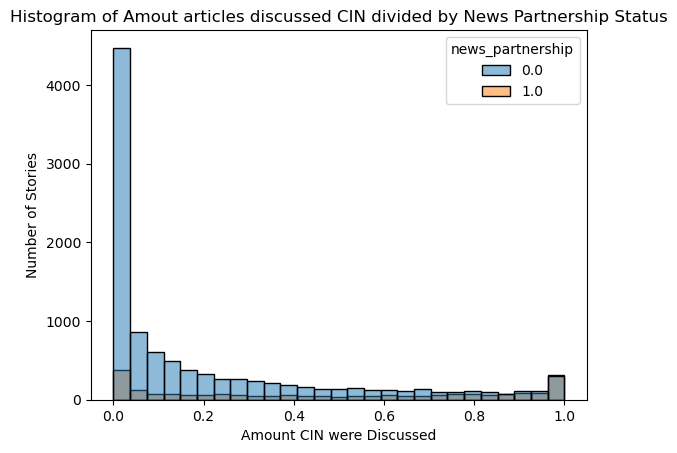

In [28]:
sns.histplot(x=ccc_df['CIN'], hue=ccc_df['news_partnership'])
plt.title("Histogram of Amout articles discussed CIN divided by News Partnership Status")
plt.xlabel("Amount CIN were Discussed")
plt.ylabel("Number of Stories")
plt.show()

##### Outliers

As seen below, there are many outliers for non news partnerships. This aligns with the histogram above.

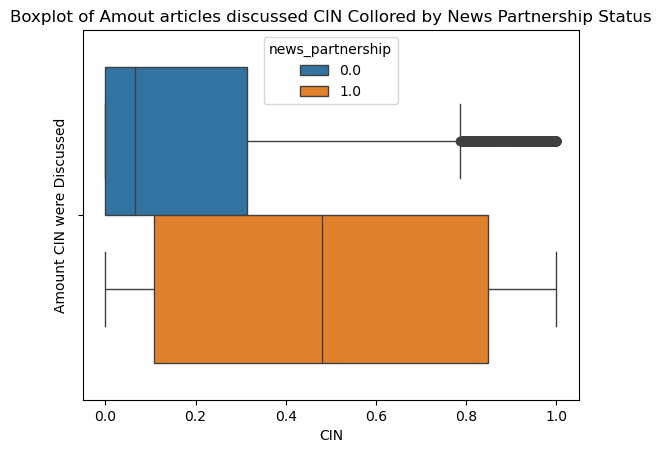

In [29]:
sns.boxplot(x=ccc_df["CIN"], hue=ccc_df['news_partnership'])
plt.title("Boxplot of Amout articles discussed CIN Collored by News Partnership Status")
plt.ylabel("Amount CIN were Discussed")
plt.show()

We will be using the Mann-Whitney U test for our hypothesis test. Nahm (2016) suggested this test or the Wilcoxon's Rank Sum test tets are equally good. We are going with the Mann-Whitney U test since its function is still being uptated while Wilcoxon's Rank Sum test is now a legacy function.

The assumptions needed for Mann-Whitney U test are not complety met. Independence has the same problems as before. In addition to that, the two samples do not have the same distribution. They are fairly similar, non news partnerships just have a more extream peak at zero. Because of this we will be continuing with the analysis.

$H_0$: mean rank sum of news partnership CIN = mean rank sum of non-news partnership CIN -- The mean rank sum articles that are apart of news partnerships discuss CIN is the same as the mean rank sum of articles not apart of news partnerships discuss CIN.

$H_a$: mean rank sum of news partnership CIN > mean rank sum of non-news partnership CIN -- The mean rank sum amount articles that are apart of news partnerships discuss CIN is larger than the mean rank sum amount articles not apart of news partnerships discuss CIN due to their different missions.

In [30]:
np = ccc_df[ccc_df['news_partnership']==1]
not_np = ccc_df[ccc_df['news_partnership']==0]

In [31]:
np_test = stats.mannwhitneyu(x=np['CIN'], y=not_np['CIN'], alternative='greater')
np_test

MannwhitneyuResult(statistic=np.float64(17129860.0), pvalue=np.float64(9.169161862502843e-259))

Because our p-value of 9.169e-259 is less than our chosen significance level of 0.01, we have extreamly strong evidence to reject the null hypothesis. This means we have evidence in favor of the alternative hypothesis that the mean rank sum articles that are apart of news partnerships discuss CIN is larger than the mean rank sum articles not apart of news partnerships discuss CIN. In the context of our study, this means we have evidence that articles from news partnerships discuss CIN more than non-news partnerships.

#### LNA comparison

We will be using a 2-sample t-test to determine if LNA discuss CIN more than non LNA. The assumptions are independence between and within samples, normality for both samples, and equal variance.

##### Independence

Independence is not fully met. Most of the observations within samples are independent, but some may come from the same institution. The main reason independence is not met is because there are many areas that are LNA (or adjacent to one) and they are often located in similar places (more rural areas). This means the are not truely independent as knowing one location is a LNA would provide me some information about other areas, but we will continue with our analysis regardless.

#### Normality

As seen in the density plot below normality is not met. LNA and non LNA are both right skewed. These values cannot be transformed for the same reasons as above. This means we will be doint a non-parametric t-test on them.

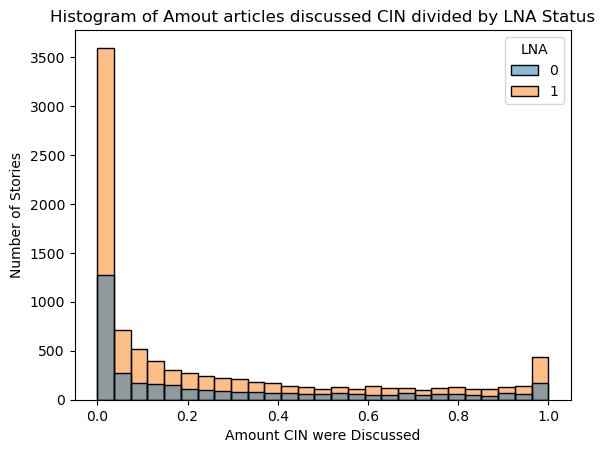

In [32]:
sns.histplot(x=ccc_df['CIN'], hue=ccc_df['LNA'])
plt.title("Histogram of Amout articles discussed CIN divided by LNA Status")
plt.xlabel("Amount CIN were Discussed")
plt.ylabel("Number of Stories")
plt.show()

##### Outliers

As seen below, there are no outliers.

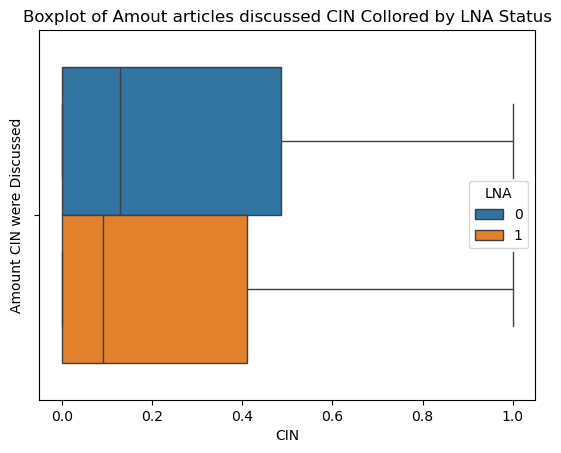

In [33]:
sns.boxplot(x=ccc_df["CIN"], hue=ccc_df['LNA'])
plt.title("Boxplot of Amout articles discussed CIN Collored by LNA Status")
plt.ylabel("Amount CIN were Discussed")
plt.show()

We will be using the Mann-Whitney U test four our hypothesis test. Nahm (2016) suggested this test or the Wilcoxon's Rank Sum test tets are equally good. We are going with the Mann-Whitney U test since its function is still being uptated while Wilcoxon's Rank Sum test is now a legacy function.

The assumptions needed for Mann-Whitney U test are mostly met. Independence has the same problems as before. The other assumption is that the samples should have the same distribution. This is met as LNA and non LNA have the same distribution, non LNA just have a higher peak at zero.

$H_0$: mean rank sum of LNA CIN = mean rank sum of non-LNA CIN -- The mean rank sum articles in or adjacent to LNA discuss CIN is the same as the mean rank sum articles not in or adjacent to LNA discuss CIN.

$H_a$: mean rank sum of LNA CIN $\neq$ mean rank sum of non-LNA CIN -- The mean rank sum articles in or adjacent to LNA discuss CIN is not the same as the mean rank sum articles not in or adjacent to LNA discuss CIN.

In [34]:
LNA = ccc_df[ccc_df['LNA']==1]
not_LNA = ccc_df[ccc_df['LNA']==0]

In [35]:
lna_test = stats.mannwhitneyu(x=LNA['CIN'], y=not_LNA['CIN'])
lna_test

MannwhitneyuResult(statistic=np.float64(15527093.5), pvalue=np.float64(6.114301888595525e-06))

Because our p-value of 6.114e-06 is less than our chosen significance level of 0.01, we have very strong evidence to reject the null hypothesis. This means we have evidence in favor of the alternative hypothesis that the mean rank sum articles in or adjacent to LNA discuss CIN is different from the mean rank sum articles not in or adjacent to LNA discuss CIN.

In [36]:
ccc_df.groupby('LNA').median(numeric_only = True)

,news_partnership,story_count,NewsOutlets2023,AdjCountyMin,word_count,news_status,Adj_news_status,CIN,Community,Mixed
LNA,,,,,,,,,,
0,0.0,20.0,21.0,3.0,673.5,0.0,0.0,0.128032,0.83046,0.0
1,0.0,17.0,4.0,1.0,619.0,0.0,1.0,0.092195,0.88215,0.0
